In [1]:
# Librerias necesarias
import pandas as pd
import numpy as np

In [3]:
# Lectura de dataframe
df = pd.read_csv('02-regression/car_fuel_efficiency_2026.csv')
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df.head()


,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


<Axes: >

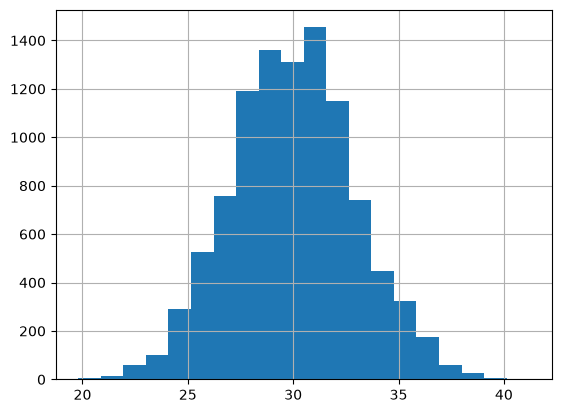

In [4]:
df['fuel_efficiency_mpg'].hist(bins=20)

### **Question 1**

There's one column with missing values. What is it?

In [5]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### **Question 2**

What's the median (50% percentile) for variable horsepower?

In [ ]:
df.describe()
#254

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


### **Prepare and split the dataset**


In [ ]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

### **Question 3**

- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
- Which option gives better RMSE?

In [14]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack((ones, X))
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

def calculate_rmse(y, y_pred):
    error = y - y_pred
    mse = (error ** 2).mean()
    rmse = np.sqrt(mse)
    return rmse

**Option 1: fill with 0**

In [16]:
train_1 = df_train.copy()
train_1.fillna(0, inplace=True)

features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
X_train = train_1[features].values
y_train = train_1['fuel_efficiency_mpg'].values
X_val = df_val[features].fillna(0).values
y_val = df_val['fuel_efficiency_mpg'].values

w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_val.dot(w)
round(calculate_rmse(y_val, y_pred), 3)

np.float64(2.205)

**Option 2: fill with train mean**

In [17]:
train_2 = df_train.copy()
hp_mean = train_2['horsepower'].mean()
train_2.fillna(hp_mean, inplace=True)

features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
X_train = train_2[features].values
y_train = train_2['fuel_efficiency_mpg'].values
X_val = df_val[features].fillna(hp_mean).values
y_val = df_val['fuel_efficiency_mpg'].values

w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_val.dot(w)
round(calculate_rmse(y_val, y_pred), 3)

np.float64(2.202)

### **Question 4**

- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
- Which r gives the best RMSE?

If multiple options give the same best RMSE, select the smallest r

In [20]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack((ones, X))
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [21]:
q4 = df_train.copy()
q4.fillna(0, inplace=True)
X_train = q4[features].values
y_train = q4['fuel_efficiency_mpg'].values
X_val = df_val[features].fillna(0).values
y_val = df_val['fuel_efficiency_mpg'].values

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r)
    y_pred = w0 + X_val.dot(w)
    rmse = round(calculate_rmse(y_val, y_pred), 4)
    print(f'For r={r}, rmse={rmse}')


For r=0, rmse=2.2053
For r=0.01, rmse=2.2058
For r=0.1, rmse=2.2241
For r=1, rmse=2.3492
For r=5, rmse=2.4094
For r=10, rmse=2.4195
For r=100, rmse=2.4292


### **Question 5**

- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

In [23]:
rmse_list = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    X_train = df_train[features].fillna(0).values
    y_train = df_train['fuel_efficiency_mpg'].values
    X_val = df_val[features].fillna(0).values
    y_val = df_val['fuel_efficiency_mpg'].values

    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val.dot(w)
    rmse = calculate_rmse(y_val, y_pred)
    rmse_list.append(rmse)

round(np.std(rmse_list), 3)

np.float64(0.029)

### **Question 6**

- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.
- What's the RMSE on the test dataset?

In [26]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_full = pd.concat([df_train, df_val])
df_full.fillna(0, inplace=True)
X_train = df_full[features].fillna(0).values
y_train = df_full['fuel_efficiency_mpg'].values
X_test = df_test[features].fillna(0).values
y_test = df_test['fuel_efficiency_mpg'].values

w0, w = train_linear_regression_reg(X_train, y_train, 0.001)
y_pred = w0 + X_test.dot(w)
calculate_rmse(y_test, y_pred)


np.float64(2.235827747191731)